In [1]:
# --- Libraries ---
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.pyplot as plt
import seaborn as sns

import os 

# --- Configuration ---
os.chdir(r"C:\Users\Alejandro\Documents\Msc Analisis Economico Cuantitativo UAM\TFM\data")

# --- Custion functions ---

from statsmodels.tsa.stattools import adfuller

# SEQUENTIAL ADF TEST
def adf_test_all(df, signif=0.01):
    results = {}
    for col in df.columns:
        series = df[col].dropna()
        adf_result = adfuller(series)
        p_value = adf_result[1]
        results[col] = {
            'ADF Statistic': adf_result[0],
            'p-value': p_value,
            'Stationary': p_value < signif
        }
    return pd.DataFrame(results).T

### 

Vamos a intentar crear un indicator de turismo de alta frecuencia a partir del numero de busquedas de las siguientes palabras, seleccionadas manualmente:
\
['madrid', 'barcelona', 'playa', 'ibiza', 'valencia', 'fiesta',
       'hotel', 'restaurante'].

1. Descargar los datos (para este ejemplo los he descargo manualmente, idealmente, usar la API)
2. Convertir las series a estacionales => calcular la tasa interanual
3. Comprobar estacionaridad => Sequential Dickey-Fuller test
4. Estandarizar los datos 

Availabe data: (266, 8)


<Axes: xlabel='Time'>

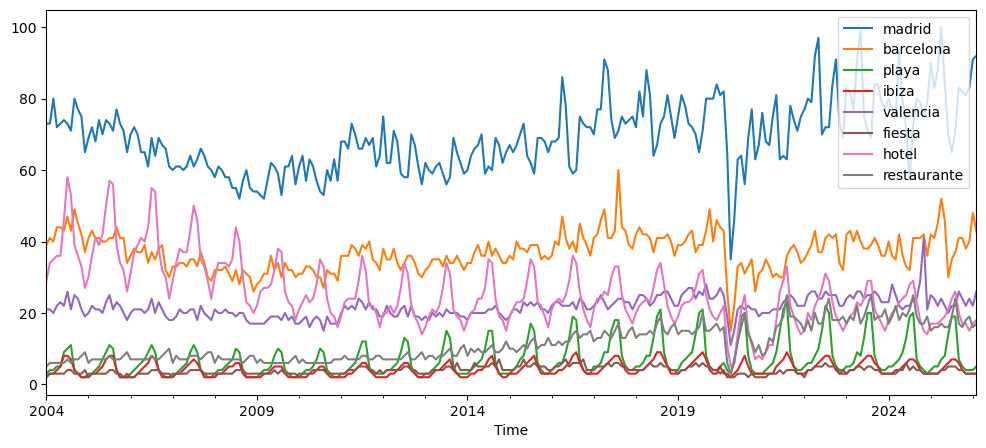

In [2]:
trend_series = pd.read_csv(r"C:\Users\Alejandro\Documents\Msc Analisis Economico Cuantitativo UAM\TFM\data\google_search_turism.csv")
trend_series["Time"] = pd.to_datetime(trend_series["Time"], format = "%Y-%m-%d")
trend_series.set_index(trend_series["Time"], inplace=True)
trend_series.drop(columns= ["Time"], inplace= True)    

print(f"Availabe data: {trend_series.shape}")
trend_series.plot(figsize=(12,5))

### Preparation of the indicator

In [3]:
# Check for stationarity

adf_test_all(trend_series, signif=0.01)

,ADF Statistic,p-value,Stationary
madrid,-0.827707,0.810848,False
barcelona,-2.320979,0.165291,False
playa,-0.992818,0.755875,False
ibiza,-1.525556,0.520833,False
valencia,-3.280762,0.015761,False
fiesta,-2.46939,0.123101,False
hotel,-2.098421,0.24515,False
restaurante,-0.758203,0.831092,False


<Axes: xlabel='Time'>

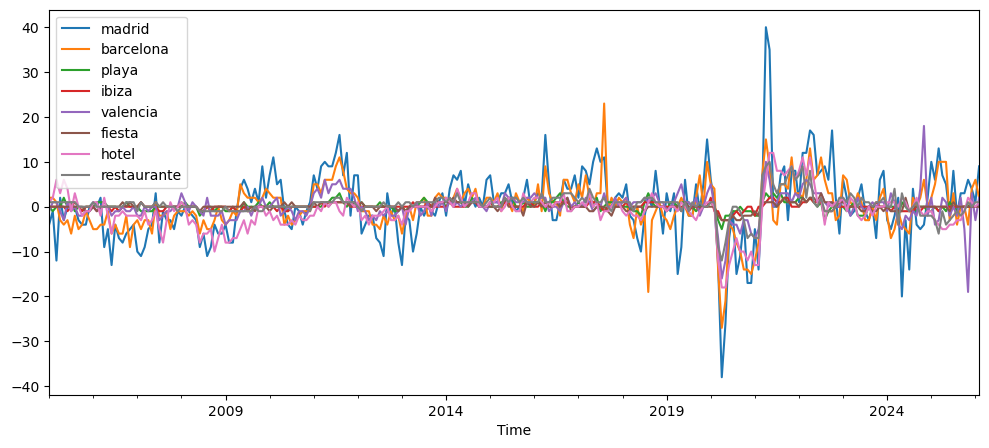

In [4]:
# Compute the yearly differences

trends_YoY = trend_series.diff(12).dropna()
trends_YoY.plot(figsize= (12,5))

In [5]:
adf_test_all(trends_YoY, signif= 0.01)

,ADF Statistic,p-value,Stationary
madrid,-3.620227,0.005386,True
barcelona,-3.606493,0.005638,True
playa,-4.504692,0.000193,True
ibiza,-4.213095,0.000626,True
valencia,-4.306802,0.000432,True
fiesta,-3.832594,0.002591,True
hotel,-4.077355,0.001055,True
restaurante,-4.562216,0.000152,True


<Axes: xlabel='Time'>

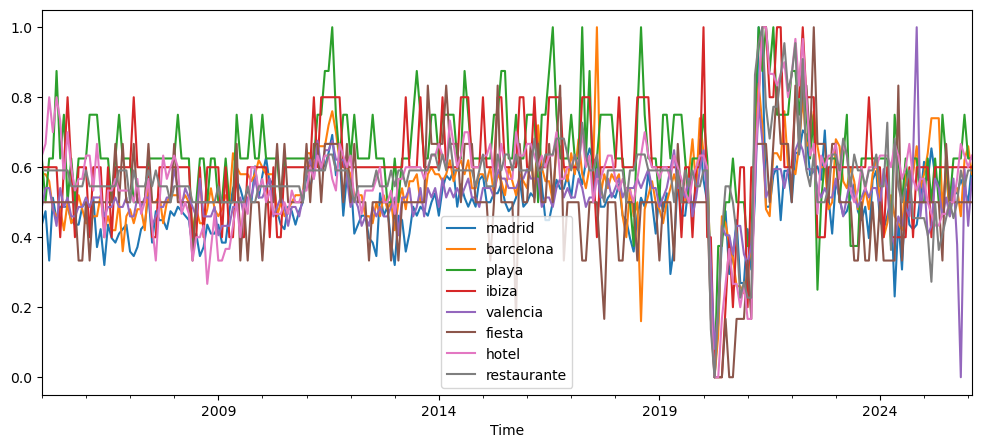

In [6]:
# Standarize the data
scaler = MinMaxScaler()
trend_series_scaled = pd.DataFrame(
    scaler.fit_transform(trends_YoY),
    index=trends_YoY.index,
    columns=trends_YoY.columns
)

trend_series_scaled.plot(figsize=(12,5))

<Axes: >

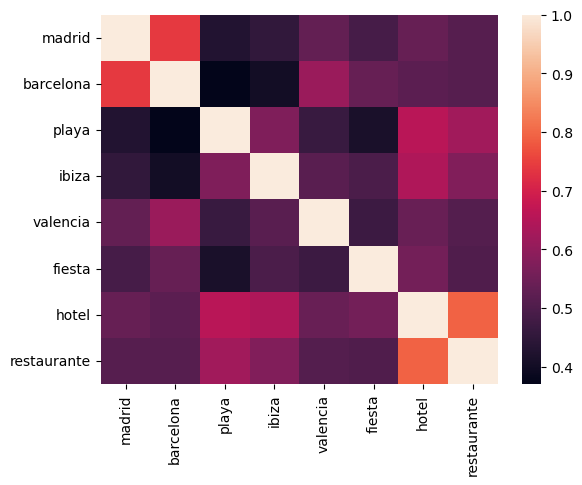

In [7]:
# Correlacion entre las series

sns.heatmap(trend_series_scaled.corr())

Text(0.5, 1.0, 'Scree Plot of Eigenvalues')

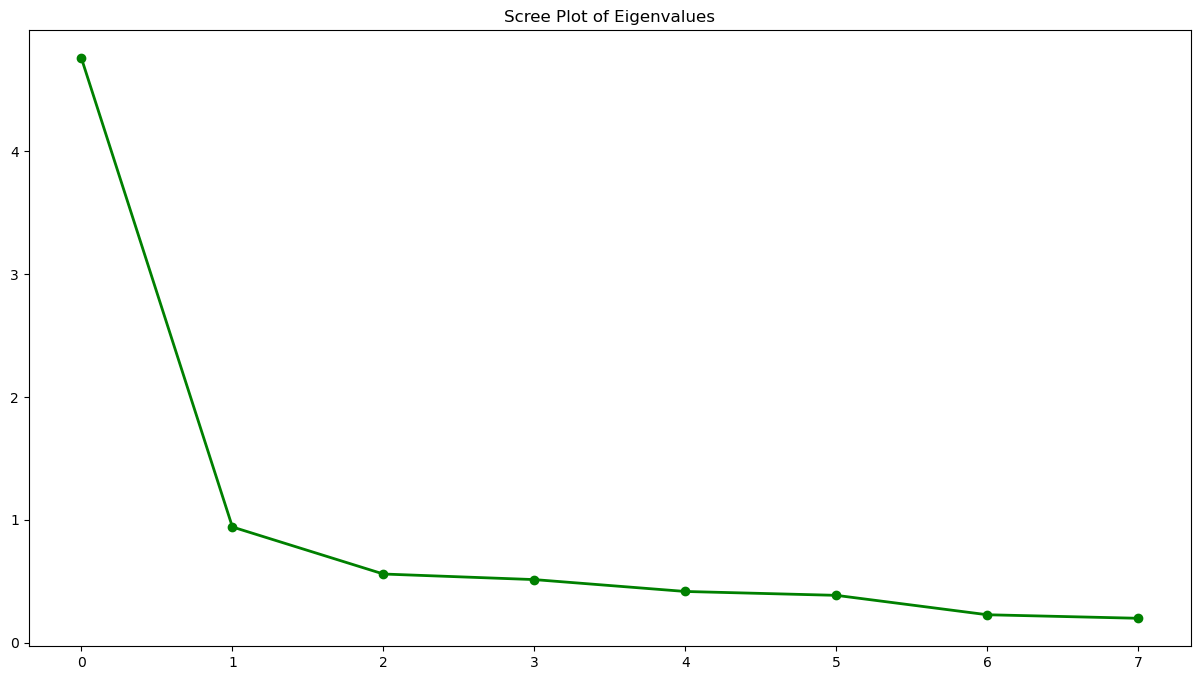

In [8]:
# Choosing the number of common factors. We will follow the scree plot methodology

eigenval, eigenvec = np.linalg.eig(trend_series_scaled.corr())
eigenval_sorted = np.sort(eigenval)[::-1]

plt.figure(figsize=(15,8))
plt.plot(eigenval_sorted, marker='o', color='green', linewidth=2)
plt.title("Scree Plot of Eigenvalues")

<Axes: >

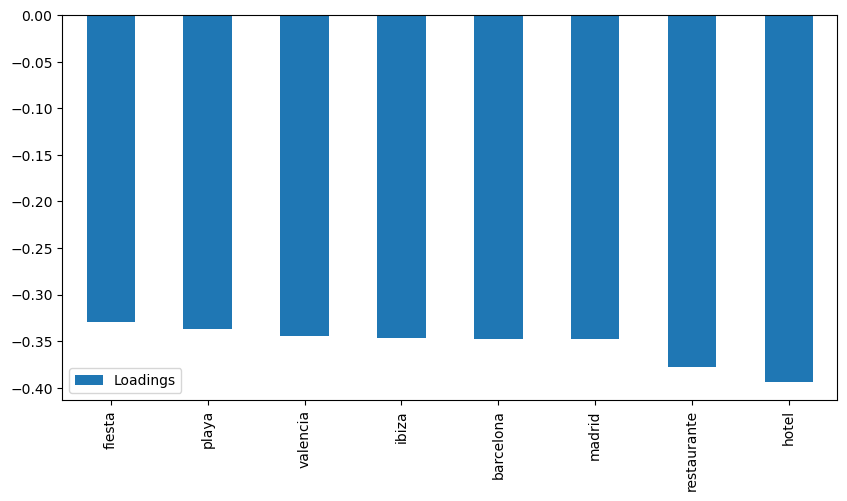

In [9]:
 # Get the corresponding eigenvector (the first principal component)
first_pc = eigenvec[:, np.argmax(eigenval)]
# Loadings dataframe
loadigns = pd.DataFrame({"Loadings": first_pc}, index= trend_series_scaled.corr().columns)
loadigns.sort_values(by = "Loadings", ascending= False).plot(kind = "bar", figsize = (10,5))


<Axes: xlabel='Time'>

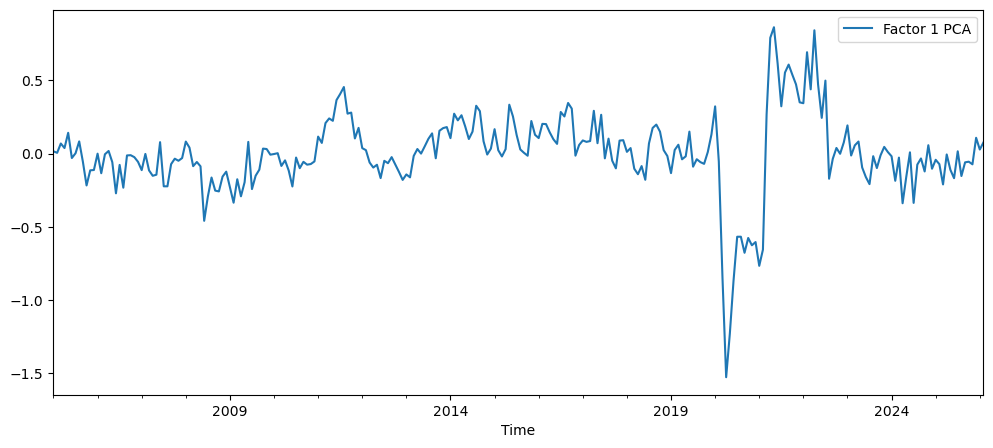

In [10]:
# Common factor estimation by PCA (diagonalization of covariance matrix)
r = 1
pca = PCA(n_components=r)
factors = pca.fit_transform(trend_series_scaled)
factors_df = pd.DataFrame(factors, 
    index=trend_series_scaled.index, 
    columns=[f"Factor {r} PCA" for r in range(1,r+1) ])

factors_df.plot(figsize=(12,5))

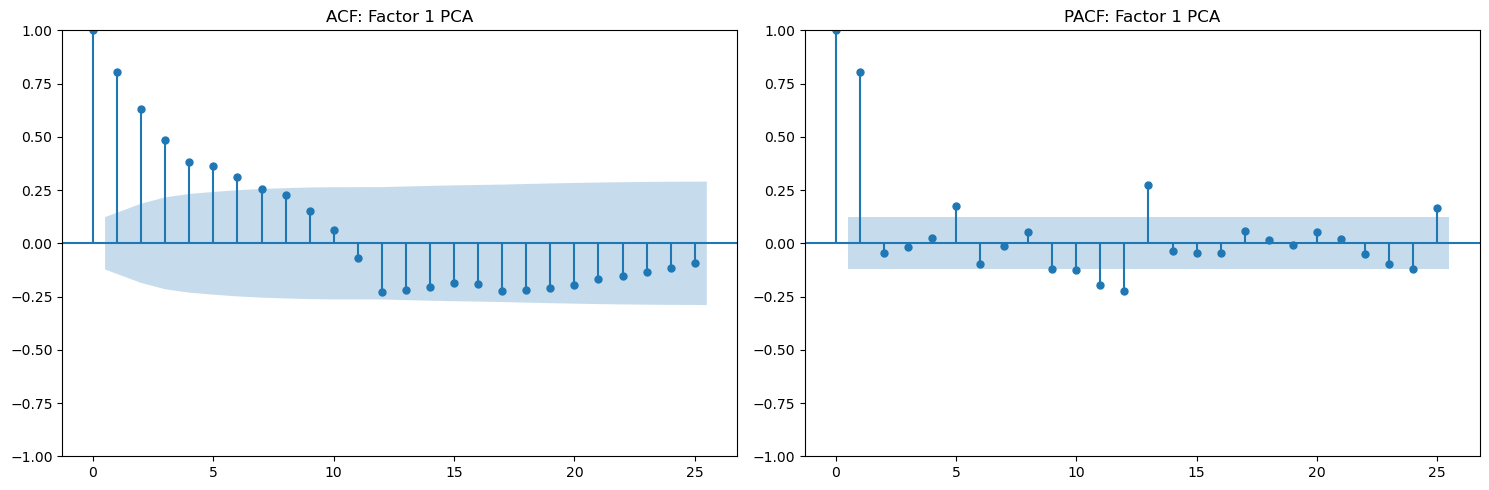

In [11]:

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Plot ACF on the first subplot (axes[0])
plot_acf(factors_df["Factor 1 PCA"].dropna(), ax=axes[0], title="ACF: Factor 1 PCA")
# Plot PACF on the second subplot (axes[1])
# Default method for pacf is 'ywm'; depending on statsmodels version you might need to specify method='ywm' to avoid warnings
plot_pacf(factors_df["Factor 1 PCA"].dropna(), ax=axes[1], title="PACF: Factor 1 PCA", method='ywm')
# Adjust layout to prevent overlap and display the graphs
plt.tight_layout()
plt.show()

c:\Users\Alejandro\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<Axes: xlabel='Time'>

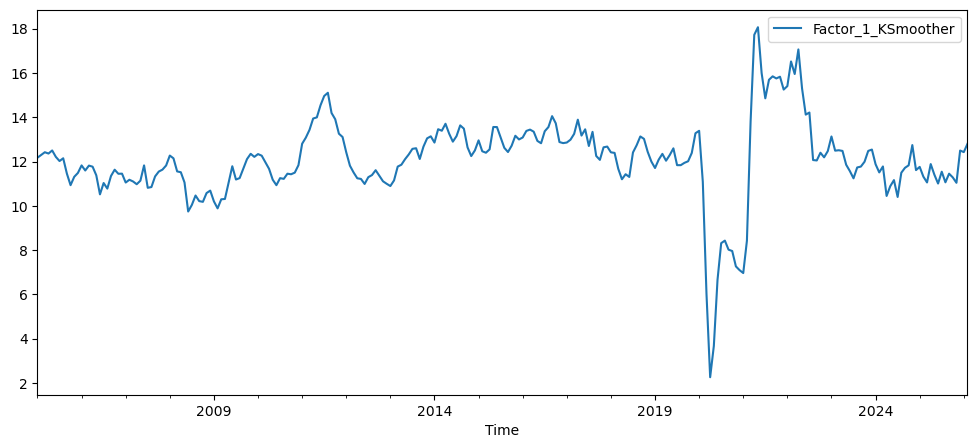

In [12]:
# Common Factor by Kalman Filter



# Modelo dinámico de factores: factores comunes + idiosincrático AR
mod = DynamicFactor(trend_series_scaled, k_factors=r, 
                    factor_order=1, # AR(1)
                    error_order=0, # White Noise
                    error_cov_type= "diagonal" #Impose Diagonalization (uncorrelated errors)
                    )

# Estimación por máxima verosimilitud (usa Kalman filter por dentro)
res = mod.fit(maxiter=1000, disp=False)

# Factores suavizados (smoothed factors) = estimación "óptima" usando toda la muestra
factors_smoothed = res.factors.smoothed  
factors_df["Factor_1_KSmoother"]  = factors_smoothed[0]

factors_df["Factor_1_KSmoother"].plot(figsize=(12,5), legend=True)


Comparamos la serie creada con algún indicador existente. En este caso, utilizamos la serie de numero de turistas del INE.

In [13]:
# Serie mensual de numero de turistas por pais de residencia 

turismo_residencia = pd.read_csv("turismo_pais_residencia.csv", sep="\t")

# Set the index to monthly_gpr for easier comparison
turismo_residencia.set_index("Periodo", inplace=True)
turismo_residencia.index = pd.to_datetime(turismo_residencia.index, format="%YM%m")

# Set the number as so
turismo_residencia["Total"] = pd.to_numeric(
    turismo_residencia["Total"].astype(str)
        .str.replace(".", "", regex=False)    
        .str.replace(",", ".", regex=False),  
    errors="coerce"
).astype("float64")  
''
# Filter for all tourists (Total) and base data only
turismo_residencia= turismo_residencia[
    (turismo_residencia["Tipo de dato"] == "Dato base")&
    (turismo_residencia["País de residencia"] == "Total")]

# Drop the now redundant columns
turismo_residencia.drop(columns=["Tipo de dato", "País de residencia"], inplace=True)
turismo_residencia = turismo_residencia.sort_index()

turismo_residencia_12d = turismo_residencia.diff(12).dropna()

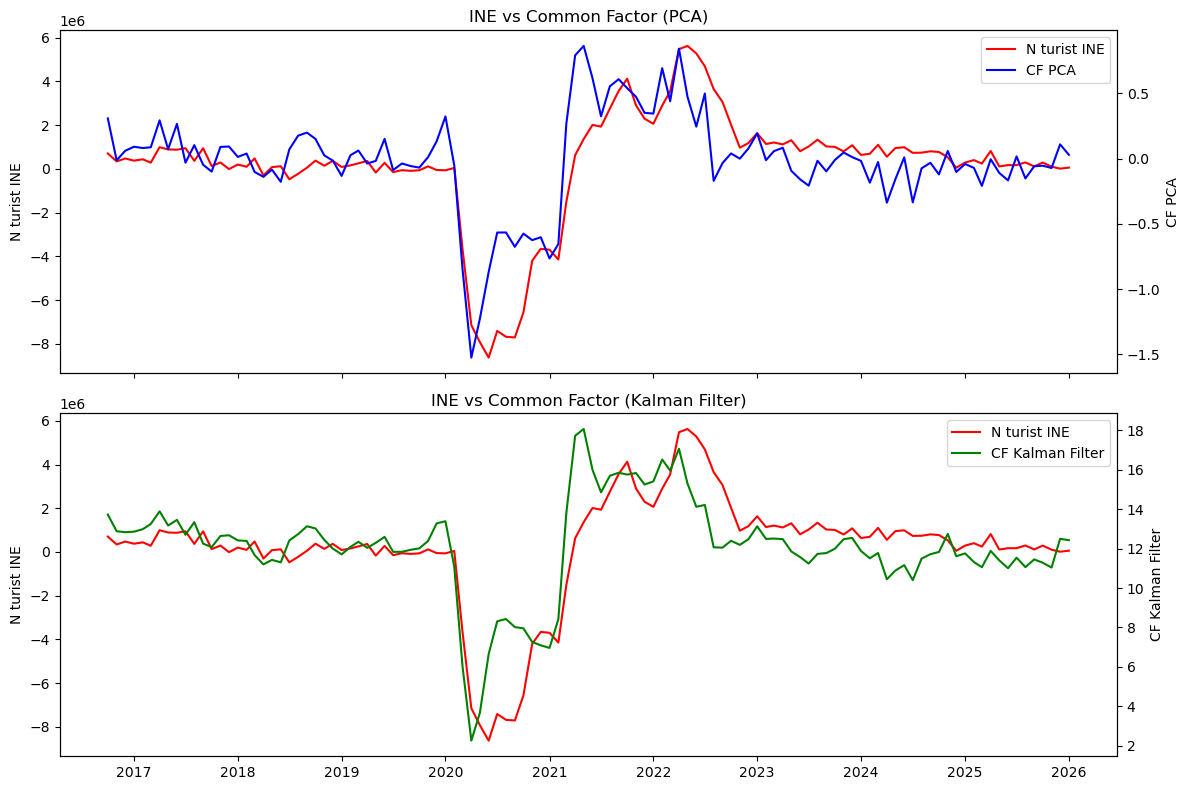

In [14]:
compare_df = pd.DataFrame({
    "CF PCA": factors_df.loc[turismo_residencia_12d.index, factors_df.columns[0]],
    "CF Kalman Filter": factors_df.loc[turismo_residencia_12d.index, factors_df.columns[1]],
    "N turist INE": turismo_residencia_12d["Total"]
}, index=turismo_residencia_12d.index)

fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# -------- Graph 1: INE vs CF PCA --------
ax1 = axes[0]

ax1.plot(compare_df.index, compare_df["N turist INE"], color="red", label="N turist INE")
ax1.set_ylabel("N turist INE")

ax1b = ax1.twinx()
ax1b.plot(compare_df.index, compare_df["CF PCA"], color="blue", label="CF PCA")
ax1b.set_ylabel("CF PCA")

ax1.set_title("INE vs Common Factor (PCA)")

lines = ax1.get_lines() + ax1b.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")


# -------- Graph 2: INE vs CF Kalman --------
ax2 = axes[1]

ax2.plot(compare_df.index, compare_df["N turist INE"], color="red", label="N turist INE")
ax2.set_ylabel("N turist INE")

ax2b = ax2.twinx()
ax2b.plot(compare_df.index, compare_df["CF Kalman Filter"], color="green", label="CF Kalman Filter")
ax2b.set_ylabel("CF Kalman Filter")

ax2.set_title("INE vs Common Factor (Kalman Filter)")

lines = ax2.get_lines() + ax2b.get_lines()
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc="best")

plt.xlabel("Fecha")
plt.tight_layout()
plt.show()

Higher (linear) correlation with the original indicator, stationarity by default (at 5%) and less RMSE, justify the use of Kalman Filter over PCA.

In [15]:
# Why use the Kalman Filter? Well...
adf_test_all(compare_df, signif=0.05)

,ADF Statistic,p-value,Stationary
CF PCA,-2.780077,0.061176,False
CF Kalman Filter,-3.027995,0.032361,True
N turist INE,-2.572323,0.098854,False


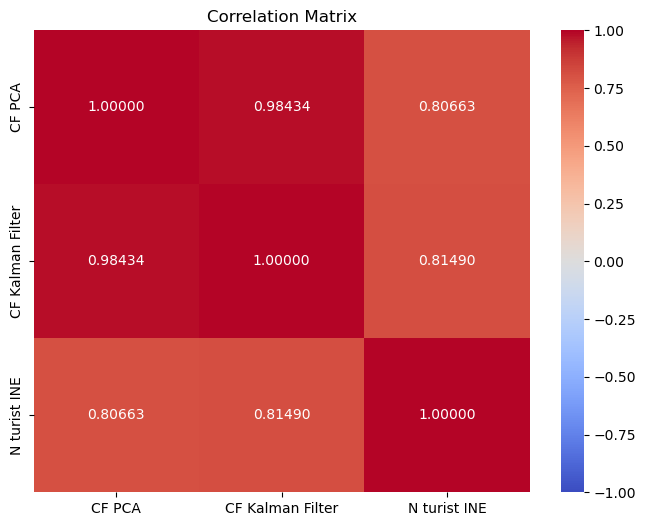

In [16]:
# Comprobamos la correlacion entre las series

plt.figure(figsize=(8, 6))
sns.heatmap(compare_df.corr(), annot=True,fmt = ".5f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

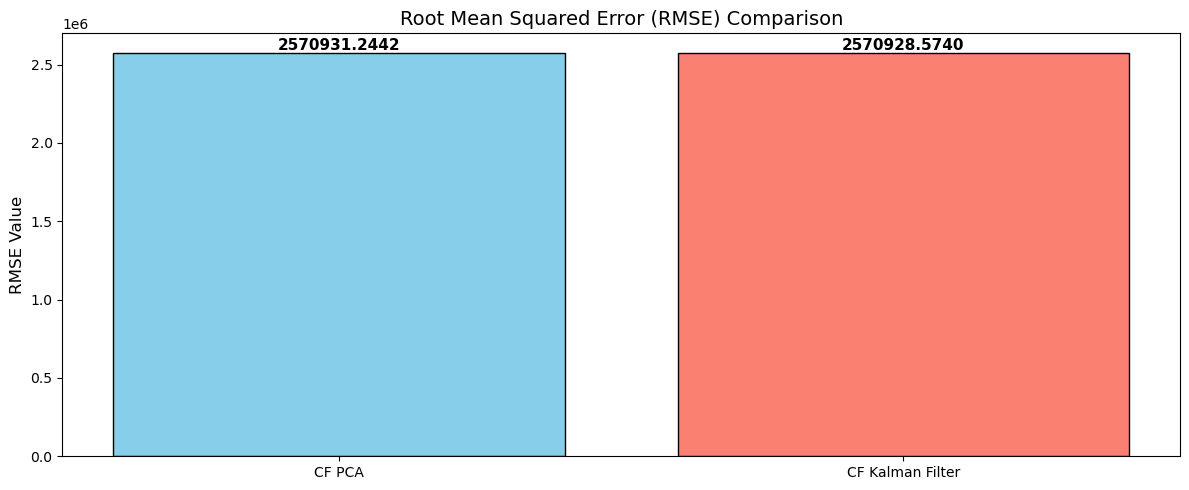

In [17]:
# Mean squared error of the series

MSE_PCA = np.sqrt(np.average((compare_df["N turist INE"] - compare_df["CF PCA"])**2))
MSE_KF = np.sqrt(np.average((compare_df["N turist INE"] - compare_df["CF Kalman Filter"])**2))


labels = ['CF PCA', 'CF Kalman Filter']
mse_values = [MSE_PCA, MSE_KF]

plt.figure(figsize=(12, 5))
bars = plt.bar(labels, mse_values, color=['skyblue', 'salmon'], edgecolor='black')
plt.title('Root Mean Squared Error (RMSE) Comparison', fontsize=14)
plt.ylabel('RMSE Value', fontsize=12)

for bar in bars:
    yval = bar.get_height()

    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.4f}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
factors_df.to_csv(r"turism_hf_indicator.csv", index=True)